In [62]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import pandas as pd

# Keep the exploratory paths close to the repository so the notebook is easy to move.
DATA_ROOT = Path("/home/julio/aws-data-pipeline-terraform/data/raw")

# EIA ERCOT day-ahead demand forecast.
forecast_payload = DATA_ROOT / "source=eia/dataset=ercot_demand_forecast/delivery_type=backfill/ingested_date=2026-08-27/request_id=ca91405b-a2df-4a6e-8196-a8da815bd412/payload.json"
forecast_metadata = DATA_ROOT / "source=eia/dataset=ercot_demand_forecast/delivery_type=backfill/ingested_date=2026-08-27/request_id=ca91405b-a2df-4a6e-8196-a8da815bd412/metadata.json"

# EIA ERCOT generation by fuel type.
ercot_fuel_type_payload = DATA_ROOT / "source=eia/dataset=ercot_fuel_type/delivery_type=backfill/ingested_date=2026-08-27/request_id=3b6070f1-9bb9-431b-a46d-bd0f0363f1a8/payload.json"
ercot_fuel_type_metadata = DATA_ROOT / "source=eia/dataset=ercot_fuel_type/delivery_type=backfill/ingested_date=2026-08-27/request_id=3b6070f1-9bb9-431b-a46d-bd0f0363f1a8/metadata.json"

# EIA Texas monthly retail electricity sales.
retail_tx_sales_payload = DATA_ROOT / "source=eia/dataset=tx_retail_sales/delivery_type=backfill/ingested_date=2026-08-27/request_id=d32d74f1-e2e1-46a5-884c-0eef77ffd00b/payload.json"
retail_tx_sales_metadata = DATA_ROOT / "source=eia/dataset=tx_retail_sales/delivery_type=backfill/ingested_date=2026-08-27/request_id=d32d74f1-e2e1-46a5-884c-0eef77ffd00b/metadata.json"

# Open-Meteo hourly Houston weather observations.
open_meteo_payload = DATA_ROOT / "source=open_meteo/dataset=texas_weather/delivery_type=backfill/ingested_date=2026-08-27/request_id=39afa992-3f32-481a-9b30-98b97a6f9ddd/payload.json"
open_meteo_metadata = DATA_ROOT / "source=open_meteo/dataset=texas_weather/delivery_type=backfill/ingested_date=2026-08-27/request_id=39afa992-3f32-481a-9b30-98b97a6f9ddd/metadata.json"

# Forecast

In [63]:
# Load the raw response and its checksum/request metadata separately.
with forecast_payload.open() as file:
    forecast_data = json.load(file)

with forecast_metadata.open() as file:
    forecast_metadata_data = json.load(file)

# EIA returns tabular values as strings, so normalize time and measure columns explicitly.
df_forecast = pd.DataFrame(forecast_data["response"]["data"])
df_forecast["period"] = pd.to_datetime(df_forecast["period"], errors="coerce")
df_forecast["value"] = pd.to_numeric(df_forecast["value"], errors="coerce")
df_forecast = df_forecast.astype({
    "respondent": "string",
    "respondent-name": "string",
    "type": "string",
    "type-name": "string",
    "value-units": "string",
})

print(f"Shape: {df_forecast.shape}")
print(f"Missing values: {df_forecast.isna().sum().to_dict()}")
df_forecast.head()

Shape: (720, 7)
Missing values: {'period': 0, 'respondent': 0, 'respondent-name': 0, 'type': 0, 'type-name': 0, 'value': 0, 'value-units': 0}


,period,respondent,respondent-name,type,type-name,value,value-units
0,2026-06-30 23:00:00,ERCO,"Electric Reliability Council of Texas, Inc.",DF,Day-ahead demand forecast,83044,megawatthours
1,2026-06-30 22:00:00,ERCO,"Electric Reliability Council of Texas, Inc.",DF,Day-ahead demand forecast,83300,megawatthours
2,2026-06-30 21:00:00,ERCO,"Electric Reliability Council of Texas, Inc.",DF,Day-ahead demand forecast,82825,megawatthours
3,2026-06-30 20:00:00,ERCO,"Electric Reliability Council of Texas, Inc.",DF,Day-ahead demand forecast,81887,megawatthours
4,2026-06-30 19:00:00,ERCO,"Electric Reliability Council of Texas, Inc.",DF,Day-ahead demand forecast,79961,megawatthours


In [64]:
## Check unique values from discrete columns
df_forecast.nunique()


period             720
respondent           1
respondent-name      1
type                 1
type-name            1
value              712
value-units          1
dtype: int64

In [65]:
df_forecast.info()

<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   period           720 non-null    datetime64[us]
 1   respondent       720 non-null    string        
 2   respondent-name  720 non-null    string        
 3   type             720 non-null    string        
 4   type-name        720 non-null    string        
 5   value            720 non-null    int64         
 6   value-units      720 non-null    string        
dtypes: datetime64[us](1), int64(1), string(5)
memory usage: 39.5 KB


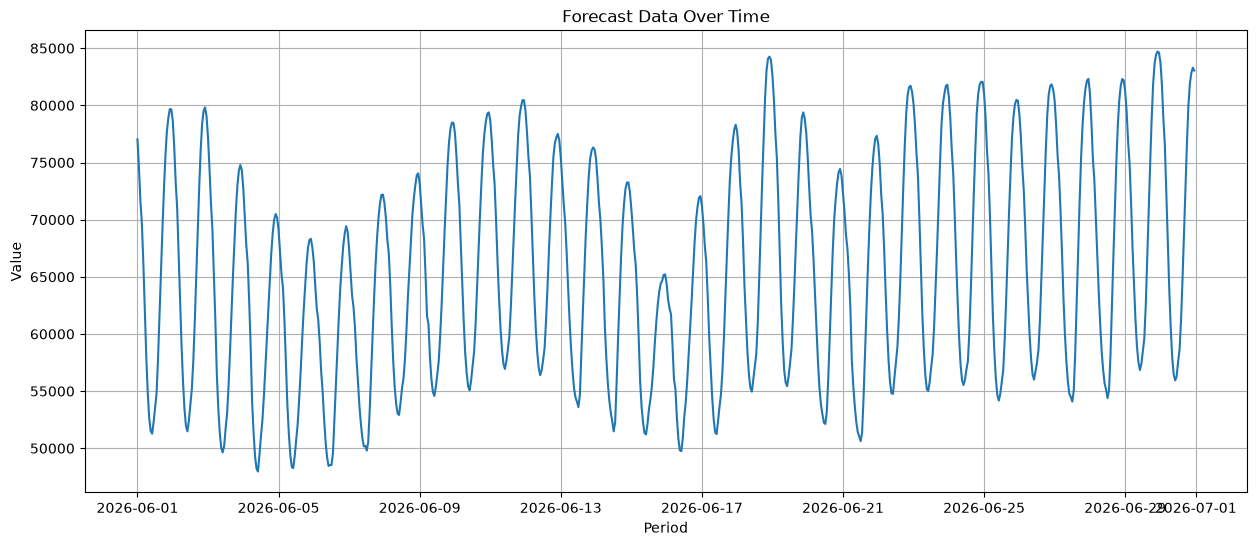

In [66]:
# Plot the lines

plt.figure(figsize=(15, 6))
plt.plot(df_forecast['period'], df_forecast['value'])
plt.xlabel('Period')
plt.ylabel('Value')
plt.title('Forecast Data Over Time')
plt.grid(True)
plt.show()

In [36]:
forecast_metadata_data

{'source_url': 'https://api.eia.gov/v2/electricity/rto/region-data/data/',
 'request_parameters': {'frequency': 'hourly',
  'data[0]': 'value',
  'facets[respondent][]': 'ERCO',
  'facets[type][]': 'DF',
  'start': '2026-06-01T00',
  'end': '2026-06-30T23',
  'length': '5000'},
 'collected_at_utc': '2026-08-27T23:40:09.734347+00:00',
 'http_status': 200,
 'payload_sha256': '10f9ceb384291fcb65164ee3e4f6832beca9c64f0ec2c68d8f062beb4d662ce8',
 'payload_s3_key': 'source=eia/dataset=ercot_demand_forecast/delivery_type=backfill/ingested_date=2026-08-27/request_id=ca91405b-a2df-4a6e-8196-a8da815bd412/payload.json'}

### Forecast observations

The sample contains one hourly day-ahead demand forecast series for ERCOT. The timestamp and forecast value are now typed for time-series analysis; the metadata cell preserves the source request details.

# ERCOT fuel type

In [67]:
# Load the fuel-type response and request metadata.
with ercot_fuel_type_payload.open() as file:
    ercot_fuel_type_data = json.load(file)

with ercot_fuel_type_metadata.open() as file:
    ercot_fuel_type_metadata_data = json.load(file)

In [68]:
# Normalize the hourly generation records for grouping and plotting.
df_fuel_type = pd.DataFrame(ercot_fuel_type_data["response"]["data"])
df_fuel_type["period"] = pd.to_datetime(df_fuel_type["period"], errors="coerce")
df_fuel_type["value"] = pd.to_numeric(df_fuel_type["value"], errors="coerce")
df_fuel_type = df_fuel_type.astype({
    "respondent": "string",
    "respondent-name": "string",
    "fueltype": "string",
    "type-name": "string",
    "value-units": "string",
})

print(f"Shape: {df_fuel_type.shape}")
print(f"Missing values: {df_fuel_type.isna().sum().to_dict()}")
print(f"Fuel types: {df_fuel_type['type-name'].dropna().unique().tolist()}")
df_fuel_type.head()

Shape: (5000, 7)
Missing values: {'period': 0, 'respondent': 0, 'respondent-name': 0, 'fueltype': 0, 'type-name': 0, 'value': 0, 'value-units': 0}
Fuel types: ['Battery storage', 'Coal', 'Natural Gas', 'Nuclear', 'Other', 'Solar', 'Hydro', 'Wind']


,period,respondent,respondent-name,fueltype,type-name,value,value-units
0,2026-06-30 23:00:00,ERCO,"Electric Reliability Council of Texas, Inc.",BAT,Battery storage,-1054,megawatthours
1,2026-06-30 23:00:00,ERCO,"Electric Reliability Council of Texas, Inc.",COL,Coal,7740,megawatthours
2,2026-06-30 23:00:00,ERCO,"Electric Reliability Council of Texas, Inc.",NG,Natural Gas,24042,megawatthours
3,2026-06-30 23:00:00,ERCO,"Electric Reliability Council of Texas, Inc.",NUC,Nuclear,4993,megawatthours
4,2026-06-30 23:00:00,ERCO,"Electric Reliability Council of Texas, Inc.",OTH,Other,50,megawatthours


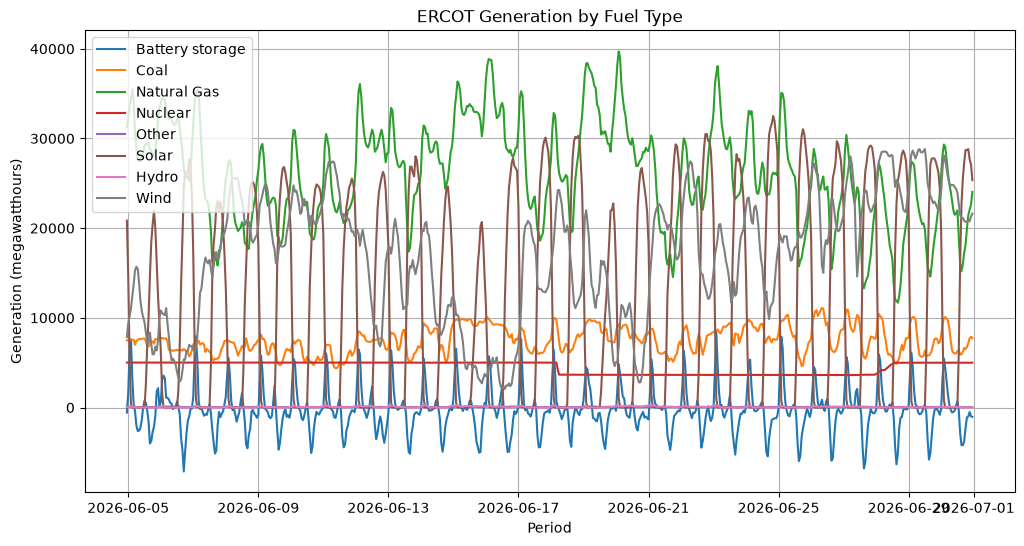

In [69]:
# Compare generation values across fuel types over time.
plt.figure(figsize=(12, 6))
for fuel_type in df_fuel_type["type-name"].dropna().unique():
    subset = df_fuel_type[df_fuel_type["type-name"] == fuel_type]
    plt.plot(subset["period"], subset["value"], label=fuel_type)
plt.xlabel("Period")
plt.ylabel("Generation (megawatthours)")
plt.title("ERCOT Generation by Fuel Type")
plt.legend()
plt.grid(True)
plt.show()

### Fuel-type observations

The backfill contains hourly generation records for multiple fuel types. The API metadata should be reviewed before production collection so request limits and pagination remain explicit.

# Retail Sales

In [70]:
# Load the retail-sales response and request metadata.
with retail_tx_sales_payload.open() as file:
    retail_tx_sales_data = json.load(file)

with retail_tx_sales_metadata.open() as file:
    retail_tx_sales_metadata_data = json.load(file)

In [71]:
# Normalize monthly retail measures. Missing numeric values remain visible as NaN.
df_retail_tx_sales = pd.DataFrame(retail_tx_sales_data["response"]["data"])
df_retail_tx_sales["period"] = pd.to_datetime(df_retail_tx_sales["period"], errors="coerce")
for column in ["price", "sales", "revenue"]:
    df_retail_tx_sales[column] = pd.to_numeric(df_retail_tx_sales[column], errors="coerce")
df_retail_tx_sales = df_retail_tx_sales.astype({
    "stateid": "string",
    "stateDescription": "string",
    "sectorid": "string",
    "sectorName": "string",
    "price-units": "string",
    "sales-units": "string",
    "revenue-units": "string",
})

print(f"Shape: {df_retail_tx_sales.shape}")
print(f"Missing values: {df_retail_tx_sales.isna().sum().to_dict()}")
print(f"Sectors: {df_retail_tx_sales['sectorName'].dropna().unique().tolist()}")
df_retail_tx_sales.head()

Shape: (6, 11)
Missing values: {'period': 0, 'stateid': 0, 'stateDescription': 0, 'sectorid': 0, 'sectorName': 0, 'price': 1, 'sales': 1, 'revenue': 1, 'price-units': 0, 'sales-units': 0, 'revenue-units': 0}
Sectors: ['all sectors', 'commercial', 'industrial', 'other', 'residential', 'transportation']


,period,stateid,stateDescription,sectorid,sectorName,price,sales,revenue,price-units,sales-units,revenue-units
0,2026-06-01,TX,Texas,ALL,all sectors,10.62,47407.74544,5036.74457,cents per kilowatt-hour,million kilowatt hours,million dollars
1,2026-06-01,TX,Texas,COM,commercial,8.66,15753.83240,1363.79822,cents per kilowatt-hour,million kilowatt hours,million dollars
2,2026-06-01,TX,Texas,IND,industrial,6.58,14676.34445,966.22505,cents per kilowatt-hour,million kilowatt hours,million dollars
3,2026-06-01,TX,Texas,OTH,other,NaN,NaN,NaN,cents per kilowatt-hour,million kilowatt hours,million dollars
4,2026-06-01,TX,Texas,RES,residential,15.94,16977.55096,2706.71995,cents per kilowatt-hour,million kilowatt hours,million dollars


### Retail-sales observations

This sample contains six sector rows for one monthly period, not a daily time series. The missing price, sales, and revenue values are preserved as nulls and should be investigated against the source API before downstream aggregation.

# Open-Meteo weather

In [72]:
# Load the weather response and request metadata.
with open_meteo_metadata.open() as file:
    meteo_metadata = json.load(file)

with open_meteo_payload.open() as file:
    meteo_payload = json.load(file)

In [73]:
# Inspect the top-level sections returned by Open-Meteo.
meteo_payload.keys()

dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly'])

In [74]:
# Convert hourly weather observations to an analysis-ready frame.
df_meteo = pd.DataFrame(meteo_payload["hourly"])
df_meteo["time"] = pd.to_datetime(df_meteo["time"], errors="coerce", utc=True)
for column in ["temperature_2m", "direct_normal_irradiance", "wind_speed_10m"]:
    df_meteo[column] = pd.to_numeric(df_meteo[column], errors="coerce")

print(f"Shape: {df_meteo.shape}")
print(f"Missing values: {df_meteo.isna().sum().to_dict()}")
df_meteo.info()
df_meteo.head()

Shape: (720, 4)
Missing values: {'time': 0, 'temperature_2m': 0, 'direct_normal_irradiance': 0, 'wind_speed_10m': 0}
<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype              
---  ------                    --------------  -----              
 0   time                      720 non-null    datetime64[us, UTC]
 1   temperature_2m            720 non-null    float64            
 2   direct_normal_irradiance  720 non-null    float64            
 3   wind_speed_10m            720 non-null    float64            
dtypes: datetime64[us, UTC](1), float64(3)
memory usage: 22.6 KB


,time,temperature_2m,direct_normal_irradiance,wind_speed_10m
0,2026-06-01 00:00:00+00:00,25.6,0.0,4.5
1,2026-06-01 01:00:00+00:00,25.1,0.0,4.4
2,2026-06-01 02:00:00+00:00,24.9,0.0,4.1
3,2026-06-01 03:00:00+00:00,24.5,0.0,3.1
4,2026-06-01 04:00:00+00:00,24.3,0.0,2.2
